# Revenue Decline & Seasonal Analysis

Source: sales_clean.parquet, customers_clean.parquet, products_clean.parquet

Covers: YoY decline by country/category/channel, Q4 seasonality, seasonal patterns by category

### Imports

In [1]:
import pandas as pd
from src.analysis import decline as dc
from src.viz import base

### Load Data

In [2]:
sales     = pd.read_parquet("../data/processed/sales_clean.parquet")
customers = pd.read_parquet("../data/processed/customers_clean.parquet")
products  = pd.read_parquet("../data/processed/products_clean.parquet")

print("sales   :", sales.shape)
print("customers:", customers.shape)
print("products :", products.shape)

sales   : (62884, 19)
customers: (15266, 12)
products : (2517, 13)


## Revenue by Year and Channel

,Order Date Year,Channel,Revenue USD
0,2016,In-Store,6011398.47
1,2016,Online,1224361.29
2,2017,In-Store,6297073.37
3,2017,Online,1415616.98
4,2018,In-Store,10676317.29
5,2018,Online,2701493.83
6,2019,In-Store,14700279.23
7,2019,Online,3932588.11
8,2020,In-Store,7393485.64
9,2020,Online,2097930.06


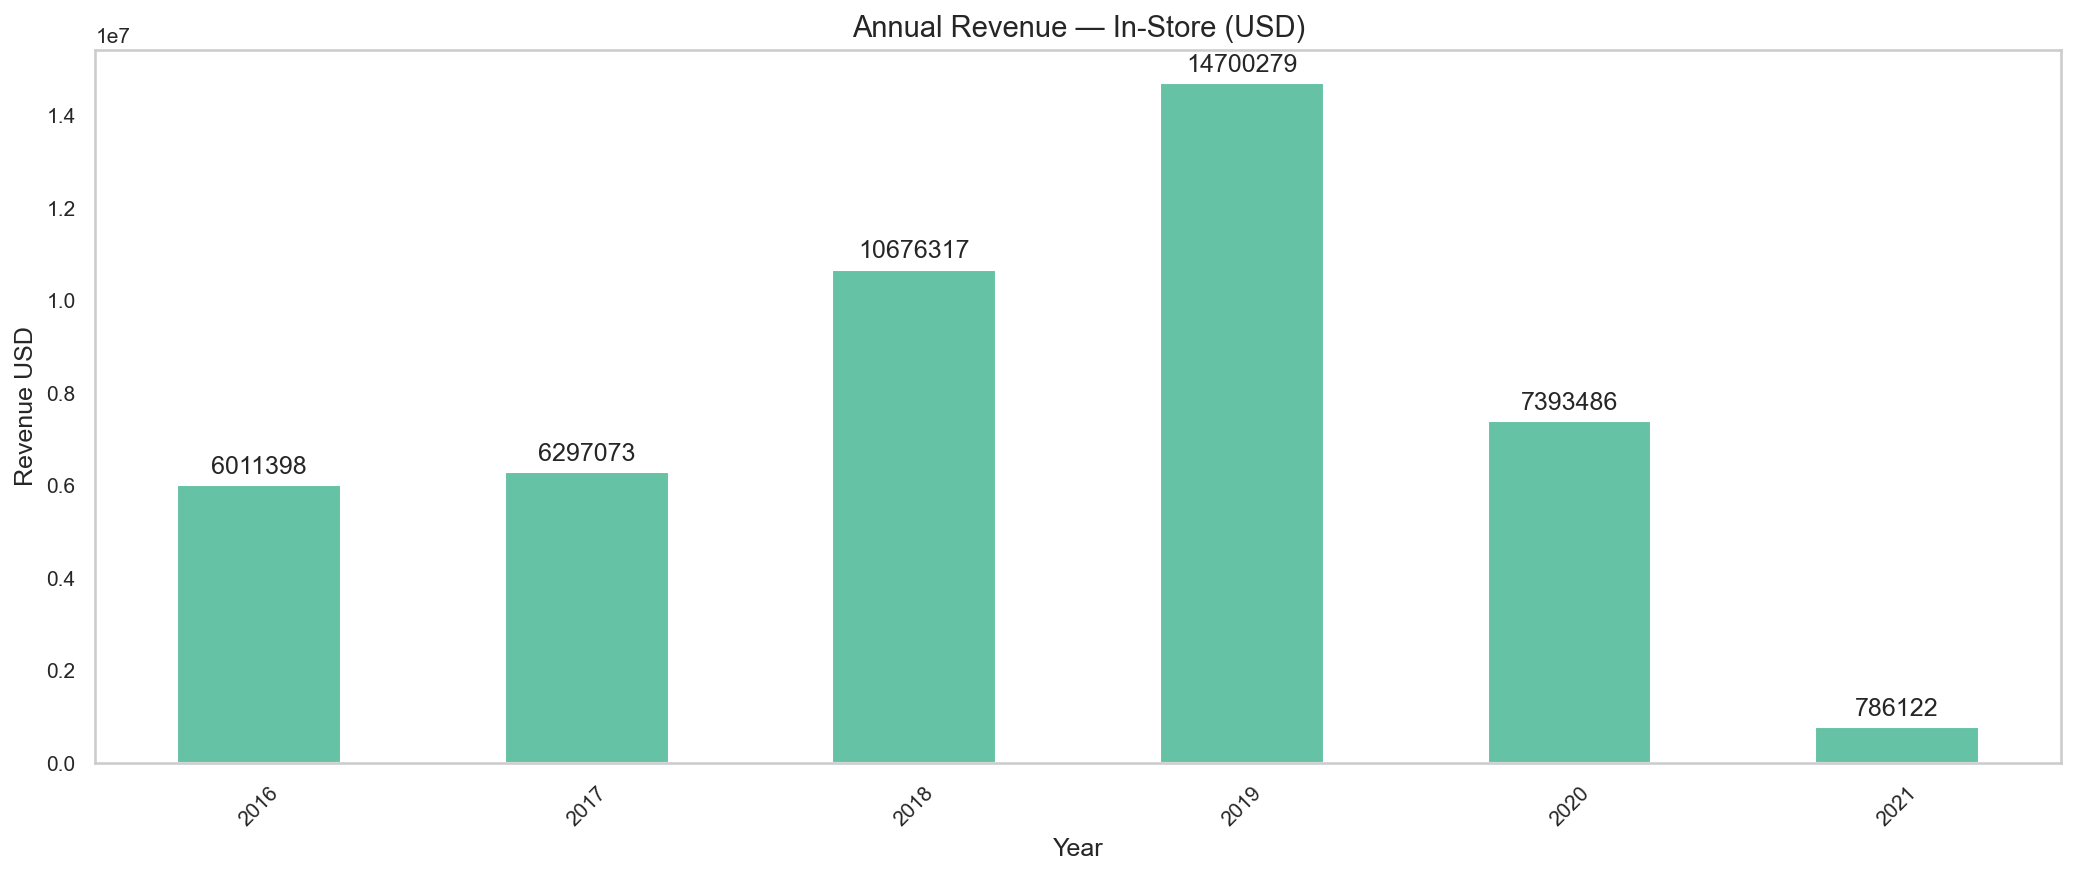

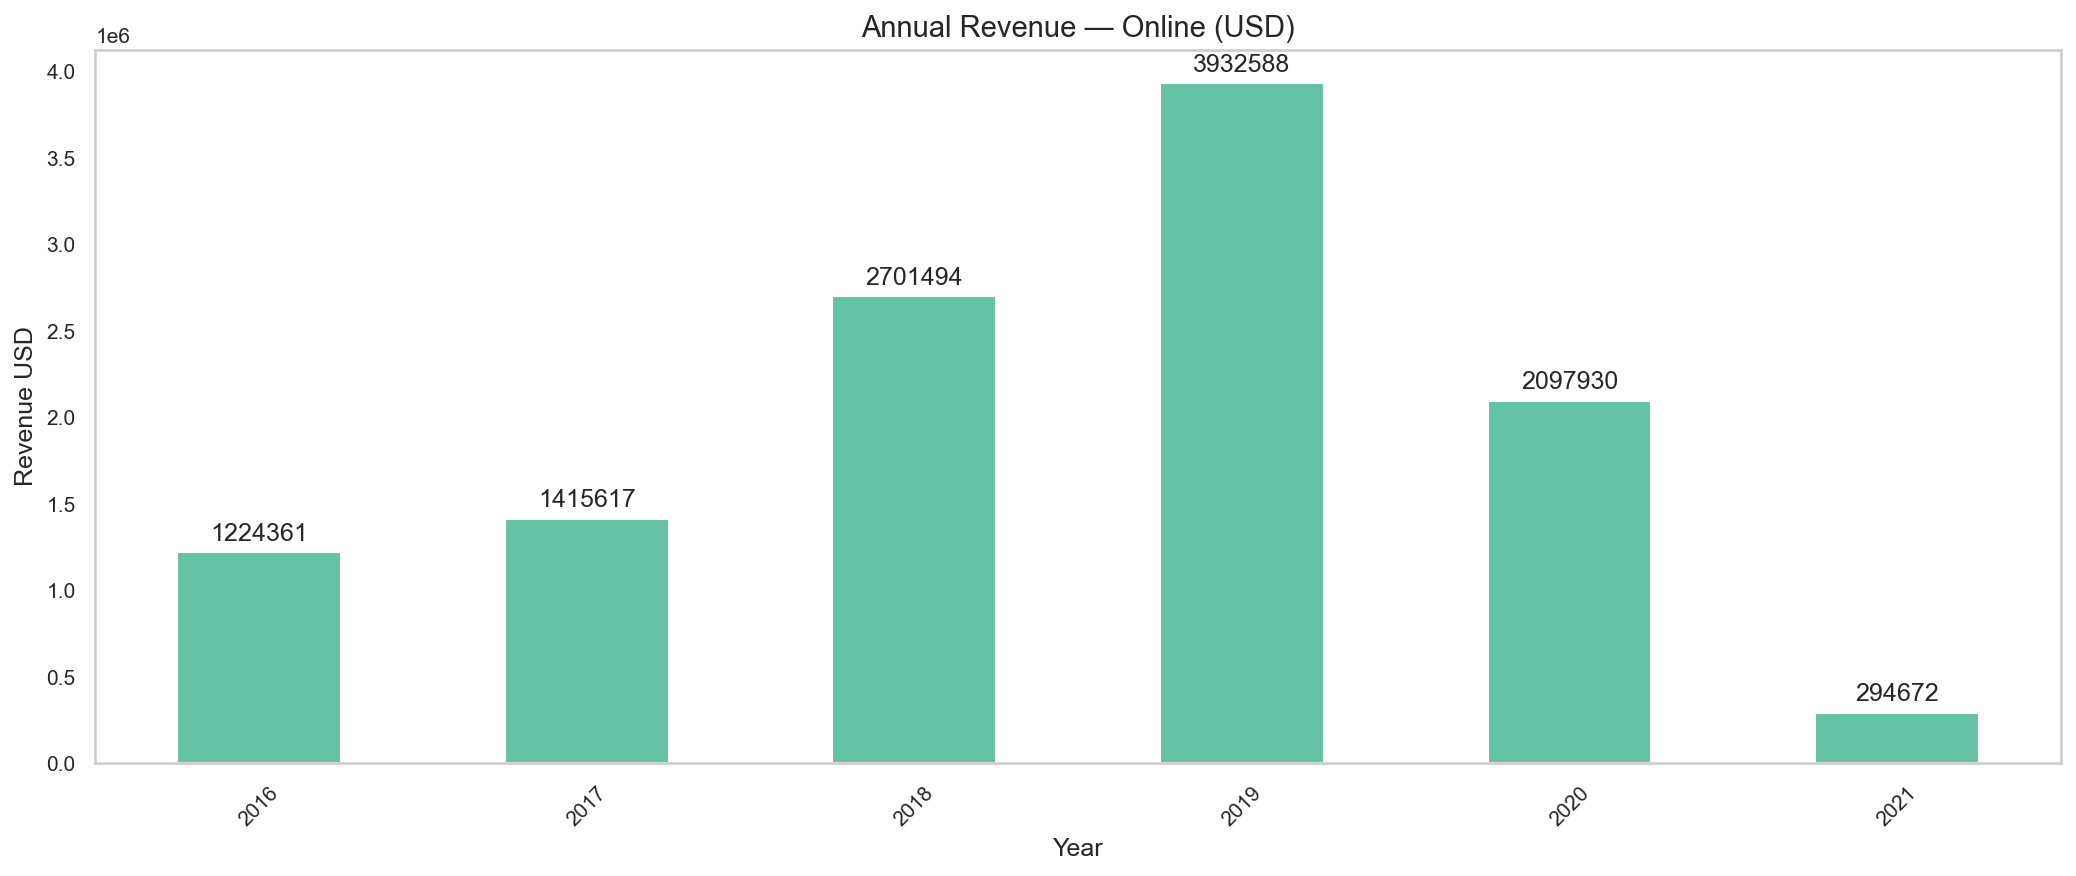

In [3]:
yr_channel = dc.revenue_by_year_channel(sales)
display(yr_channel)
for channel, grp in yr_channel.groupby("Channel"):
    fig, ax = base.bar(
        grp.set_index("Order Date Year")["Revenue USD"],
        title=f"Annual Revenue — {channel} (USD)",
        xlabel="Year", ylabel="Revenue USD",
        filename=f"decline_annual_{channel.lower().replace('-','_')}.png"
    )
    display(fig)

## YoY Growth by Country (2019 → 2020 decline focus)

,Order Date Year,Country,Revenue USD,Prev Revenue,YoY Growth Pct
36,2020,Italy,343443.19,793264.56,-56.71
35,2020,Germany,962763.42,2099254.17,-54.14
32,2020,Australia,301669.26,617916.90,-51.18
33,2020,Canada,560654.79,1134723.03,-50.59
38,2020,United Kingdom,1299669.49,2607122.03,-50.15
39,2020,United States,5268961.03,10133066.38,-48.00
37,2020,Netherlands,387683.53,714996.77,-45.78
34,2020,France,366570.99,532523.50,-31.16


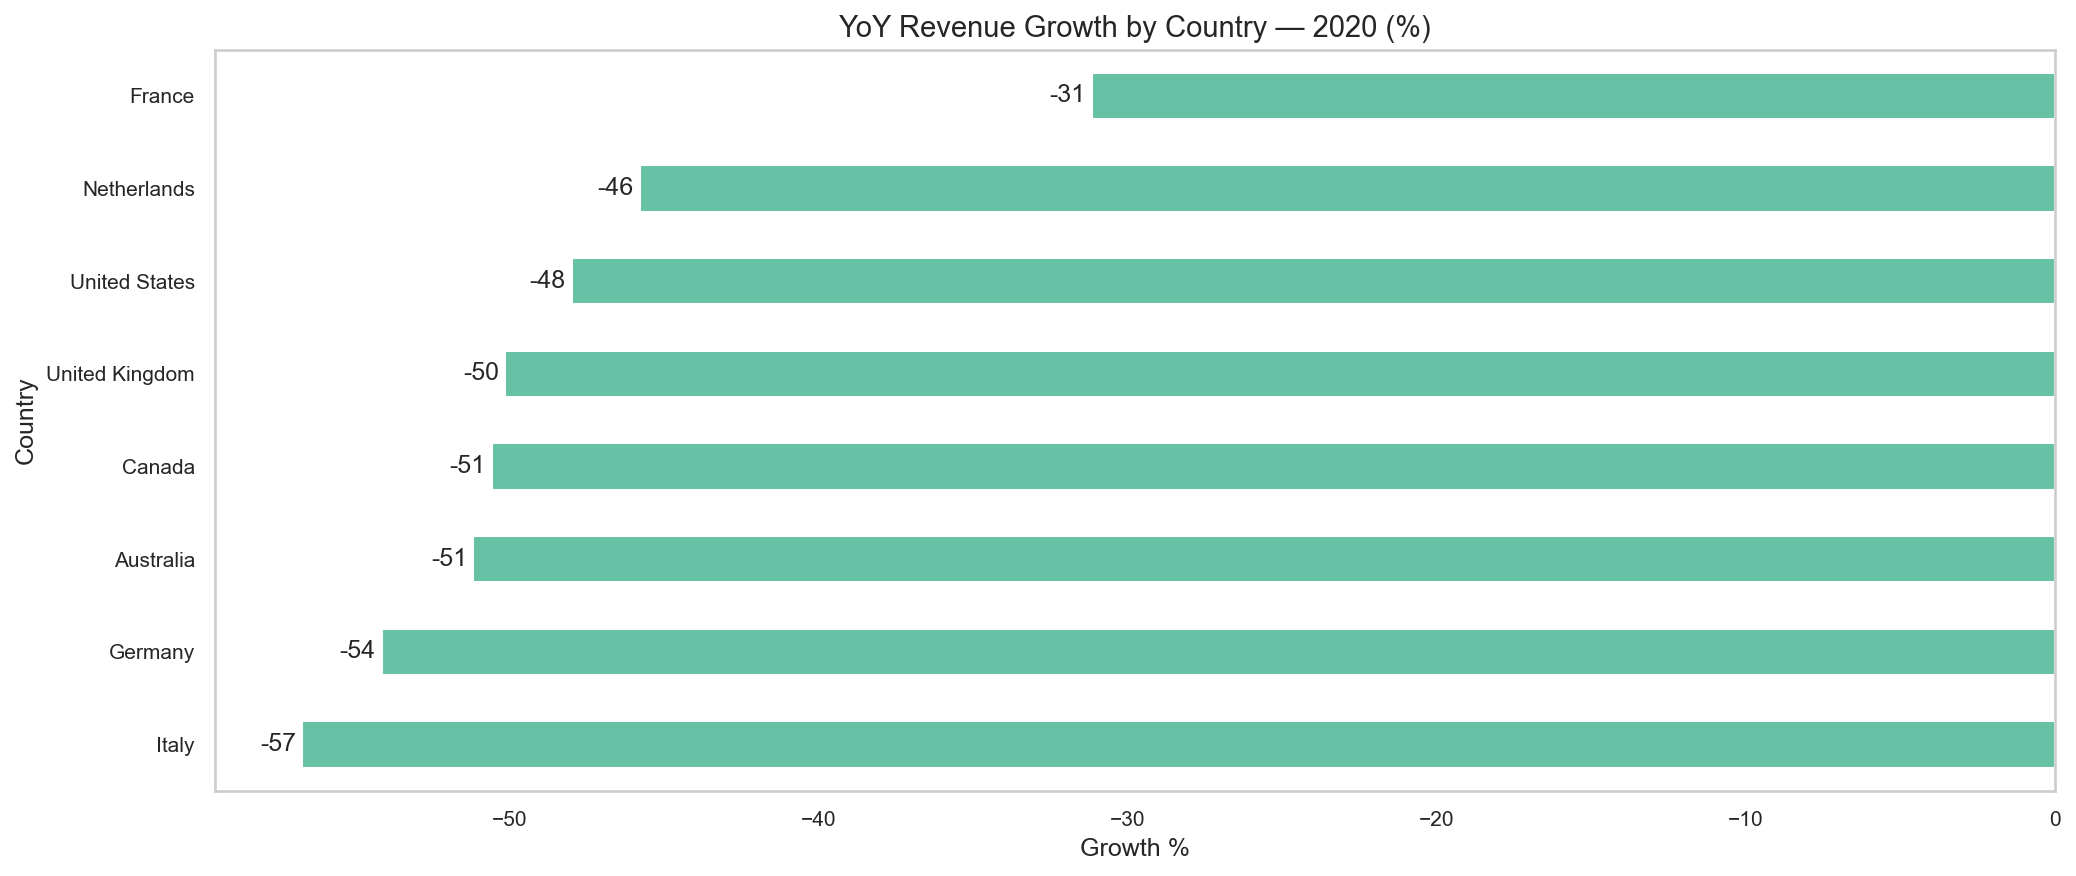

In [4]:
yoy_country = dc.yoy_by_country(sales, customers)
decline_2020 = yoy_country[yoy_country["Order Date Year"] == 2020].sort_values("YoY Growth Pct")
display(decline_2020)
fig, ax = base.horizontal_bar(
    decline_2020.set_index("Country")["YoY Growth Pct"],
    title="YoY Revenue Growth by Country — 2020 (%)",
    xlabel="Growth %", ylabel="Country",
    filename="decline_yoy_country_2020.png"
)

display(fig)

## YoY Growth by Category (2020 decline)

,Order Date Year,Category,Revenue USD,Prev Revenue,YoY Growth Pct
37,2020,Home Appliances,1129880.22,2730730.37,-58.62
32,2020,Audio,469393.94,1085750.15,-56.77
36,2020,Games and Toys,156931.64,303780.79,-48.34
35,2020,Computers,3739965.84,7114033.67,-47.43
39,2020,TV and Video,903078.59,1714798.34,-47.34
33,2020,Cameras and camcorders,1225410.37,2294032.96,-46.58
34,2020,Cell phones,1287556.63,2360852.85,-45.46
38,2020,"Music, Movies and Audio Books",579198.47,1028888.21,-43.71


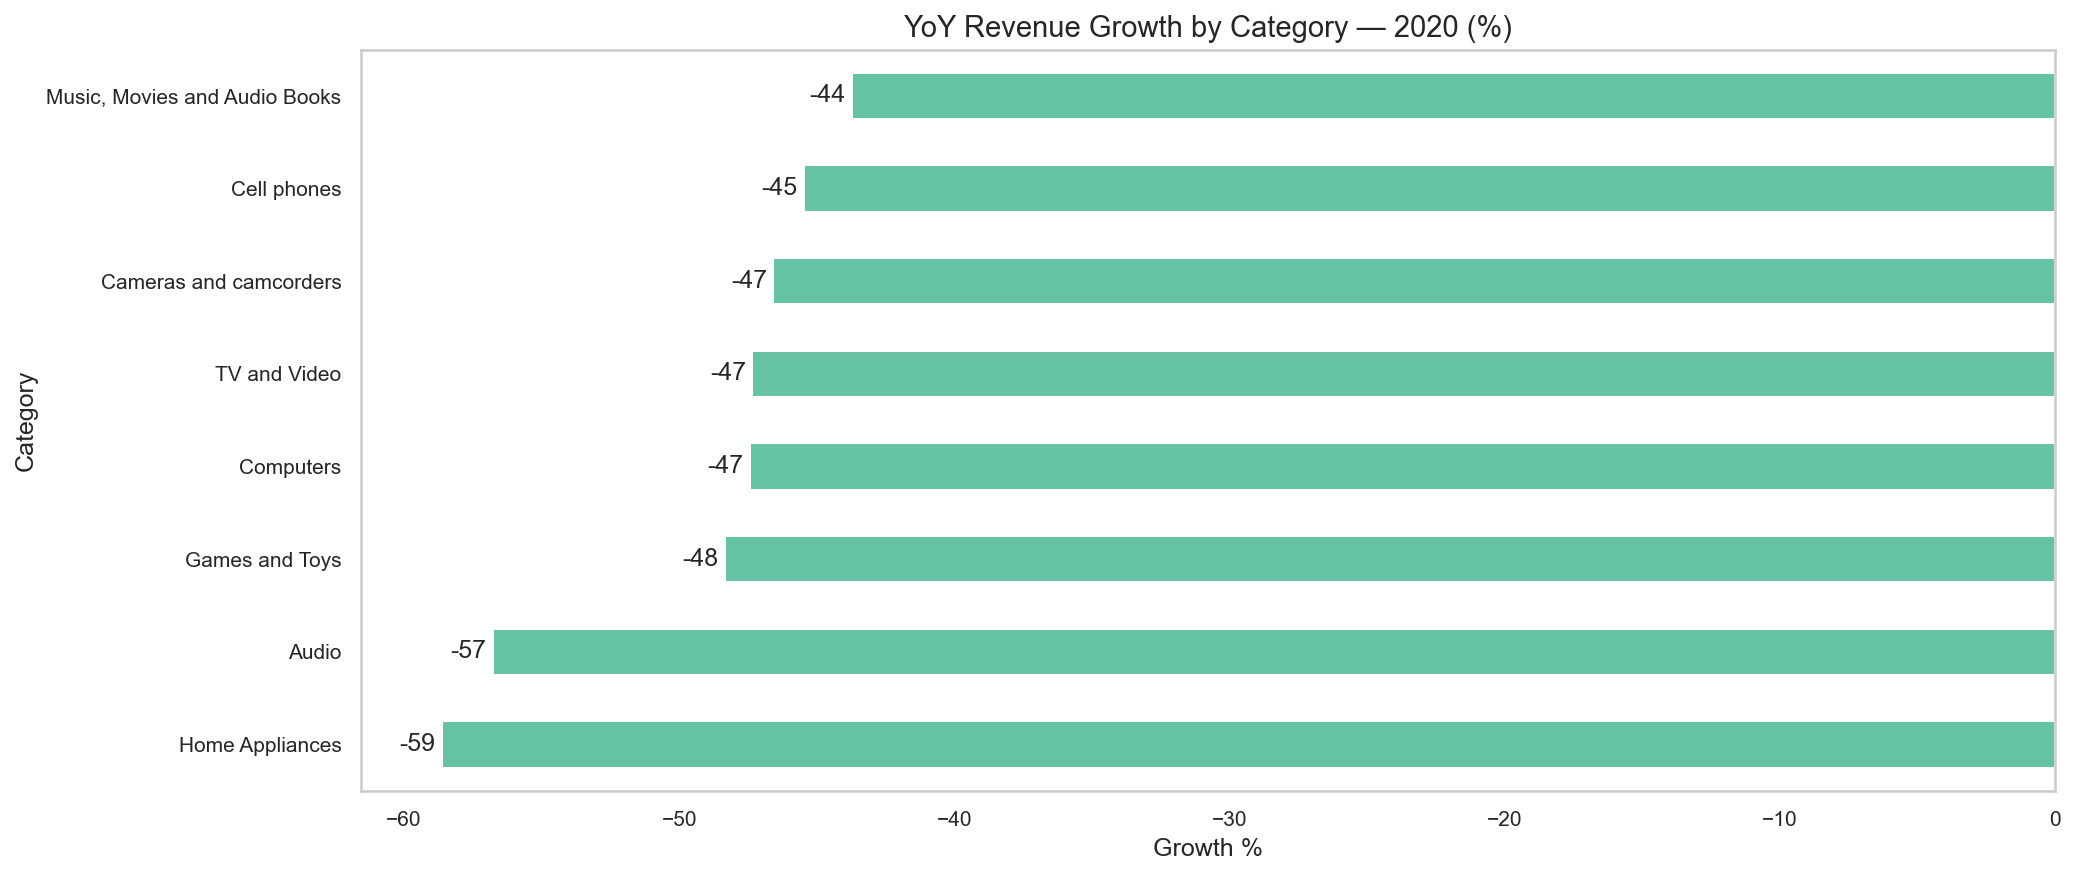

In [5]:
yoy_cat = dc.yoy_by_category(sales, products)
decline_cat_2020 = yoy_cat[yoy_cat["Order Date Year"] == 2020].sort_values("YoY Growth Pct")
display(decline_cat_2020)
fig, ax = base.horizontal_bar(
    decline_cat_2020.set_index("Category")["YoY Growth Pct"],
    title="YoY Revenue Growth by Category — 2020 (%)",
    xlabel="Growth %", ylabel="Category",
    filename="decline_yoy_category_2020.png"
)

display(fig)

## Q4 Lift — How much does Q4 outperform other quarters?

,Q4 Revenue,Avg Other Quarter,Q4 Lift Pct
Order Date Year,,,
2016,2340836.27,1.631641e+06,43.47
2017,2691844.14,1.673615e+06,60.84
2018,4962655.14,2.805052e+06,76.92
2019,5887137.15,4.248577e+06,38.57
2020,1203437.39,2.762659e+06,-56.44


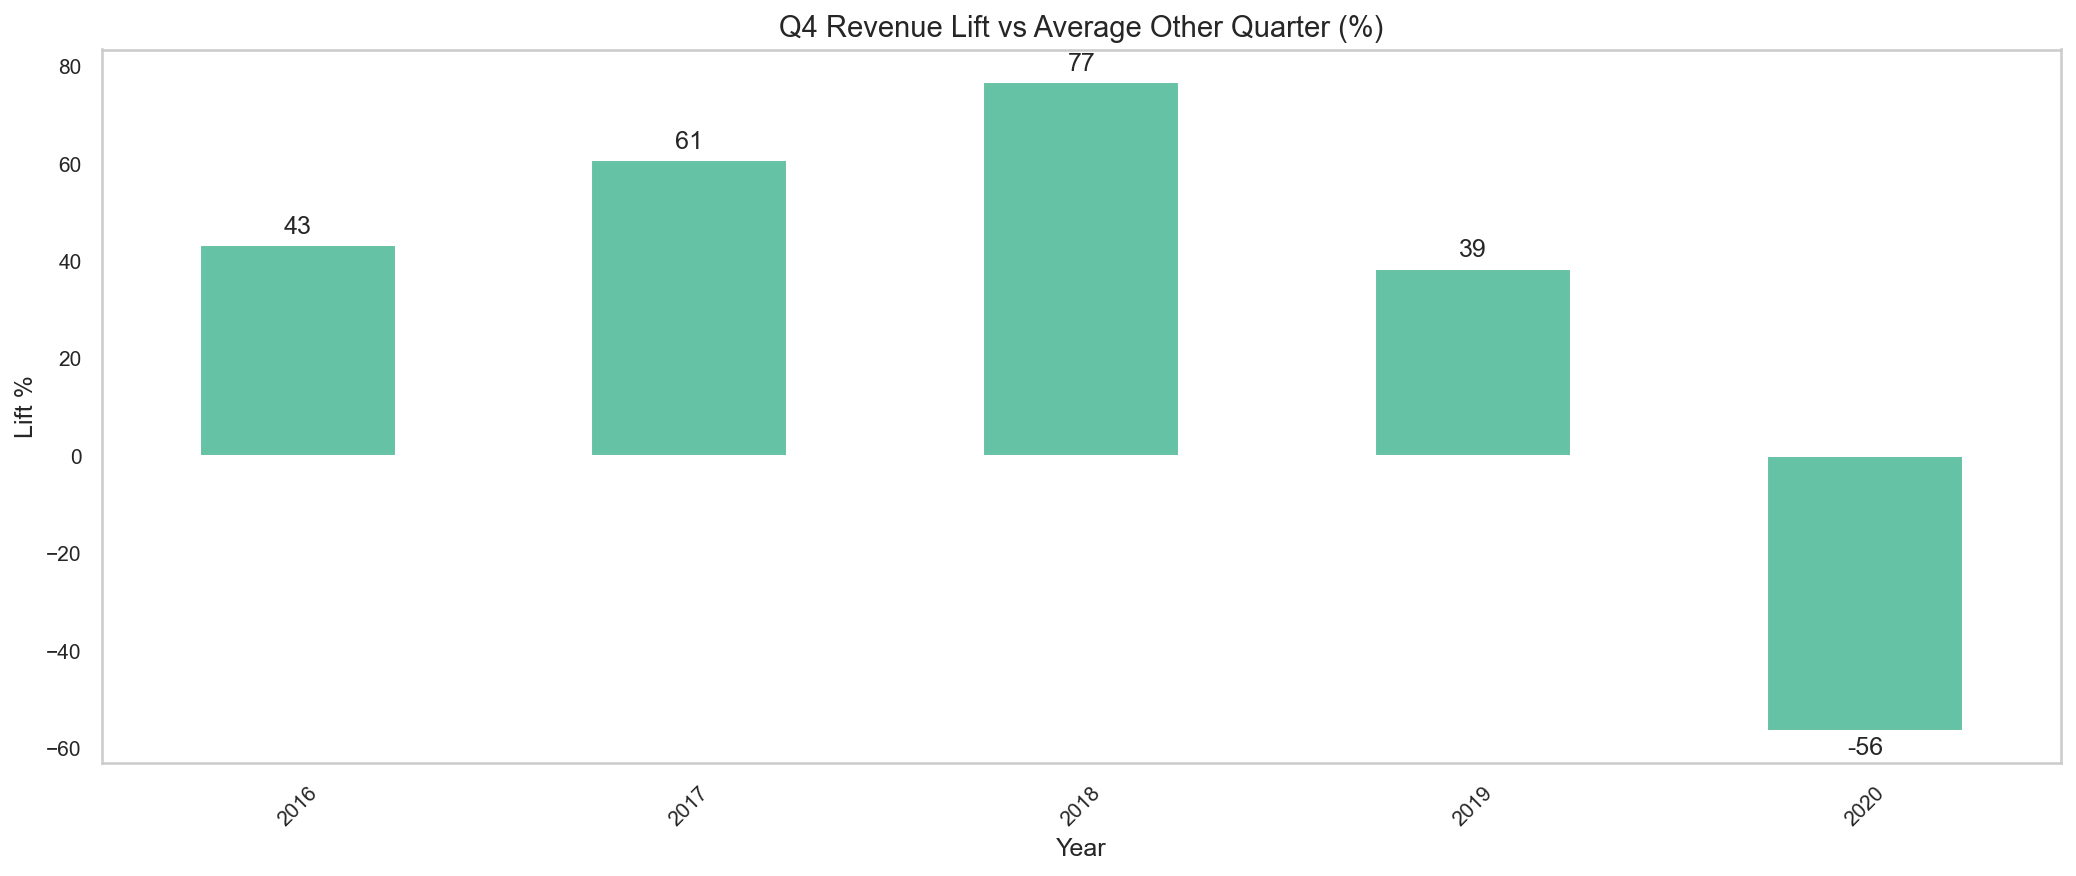

In [6]:
q4 = dc.q4_lift(sales)
display(q4)
fig, ax = base.bar(
    q4["Q4 Lift Pct"],
    title="Q4 Revenue Lift vs Average Other Quarter (%)",
    xlabel="Year", ylabel="Lift %",
    filename="seasonal_q4_lift.png"
)

display(fig)

## Seasonal Pattern by Category

In [7]:
seasonal_cat = dc.seasonal_by_category(sales, products)
display(seasonal_cat)

Category,Audio,Cameras and camcorders,Cell phones,Computers,Games and Toys,Home Appliances,"Music, Movies and Audio Books",TV and Video
Order Date Quarter,,,,,,,,
1,994361.12,2146608.48,1951504.32,6055696.96,229987.93,3581237.63,978376.52,1917433.18
2,535998.35,1177008.14,1218325.07,3383747.70,127145.09,1972253.02,534335.33,1034587.82
3,760913.85,1385760.71,1312174.72,4486035.26,167440.21,2402900.38,711043.69,1380552.89
4,980038.53,1985035.39,1912699.39,6000830.94,222967.65,3165550.69,1003773.56,1815013.94


## Revenue Decline & Seasonal — Findings

### Channel Decline
- In-Store peaked at $14.7M in 2019, dropped to $7.4M in 2020 (-50%) and $786K in 2021 (partial).
- Online peaked at $3.9M in 2019, dropped to $2.1M in 2020 (-47%) and $294K in 2021 (partial).
- Both channels declined at nearly the same rate — the drop was not channel-specific.
- In-Store took the larger absolute hit given its much higher base.

### 2020 Decline by Country
- Every single country declined in 2020 — this was a global event, not market-specific.
- France held up best at -31% — the least affected of all markets.
- Italy was hit hardest at -57%, followed by Germany at -54%.
- US declined -48%, UK -50% — both major markets took significant hits.
- No country was resilient enough to offset declines elsewhere.

### 2020 Decline by Category
- Again every category declined — no category was immune.
- Music, Movies and Audio Books was least affected at -44%.
- Home Appliances (-59%) and Audio (-57%) were hit hardest.
- Computers, TV and Video, Cameras all declined -47% — mid-range impact.
- Home Appliances decline is notable given it is the second largest revenue category.

### Seasonality
- Q4 is the strongest quarter every year without exception.
- Q2 is the weakest quarter every year without exception.
- The Q4 spike is consistent and predictable — driven by holiday purchasing.